#### Task-3: Clustering Analysis – Customer Segmentation

Shape of dataset: (200, 5)
Missing values:
 CustomerID              0
Gender                  0
Age                     0
Annual_Income_k         0
Spending_Score_1-100    0
dtype: int64
Duplicate rows: 0
Data types:
 CustomerID               int64
Gender                  object
Age                      int64
Annual_Income_k          int64
Spending_Score_1-100     int64
dtype: object
Summary statistics:
        CustomerID         Age  Annual_Income_k  Spending_Score_1-100
count  200.000000  200.000000       200.000000            200.000000
mean   100.500000   38.850000        60.560000             50.200000
std     57.879185   13.969007        26.264721             25.823522
min      1.000000   18.000000        15.000000              1.000000
25%     50.750000   28.750000        41.500000             34.750000
50%    100.500000   36.000000        61.500000             50.000000
75%    150.250000   49.000000        78.000000             73.000000
max    200.000000   70.000000       137.

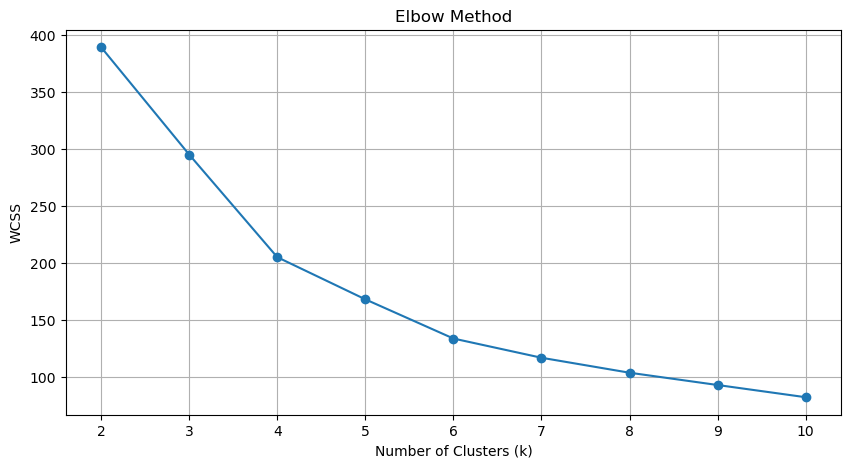

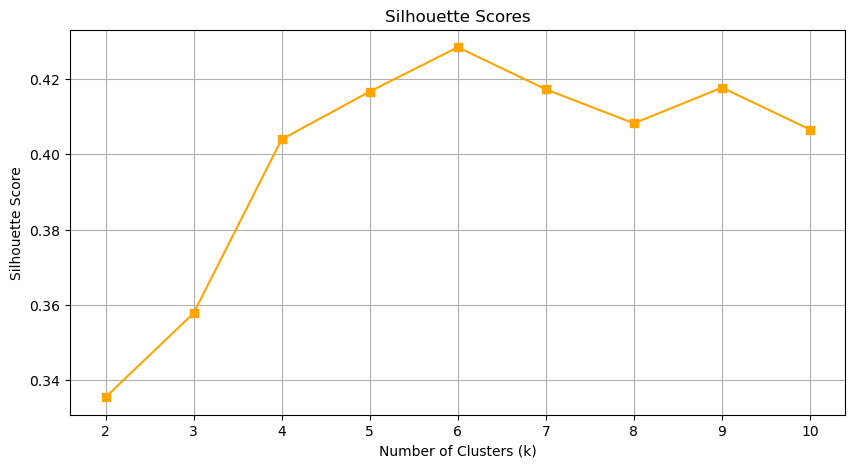

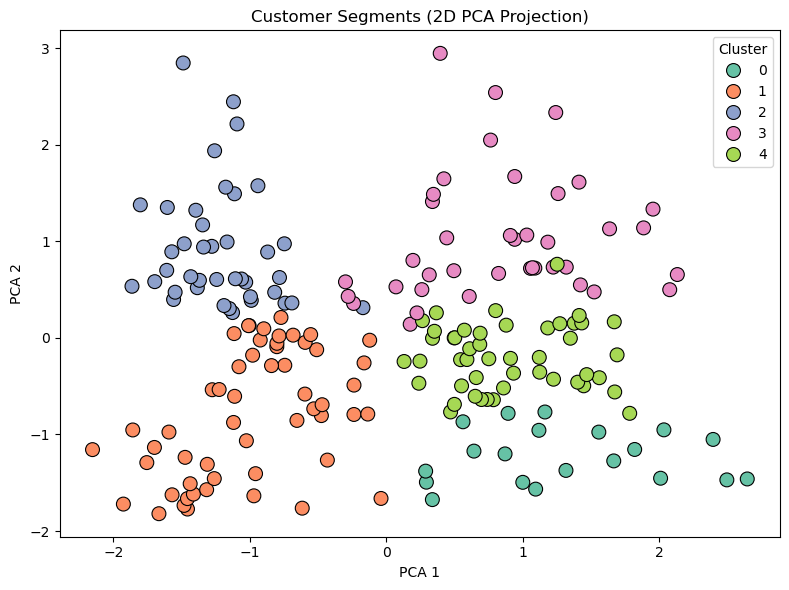

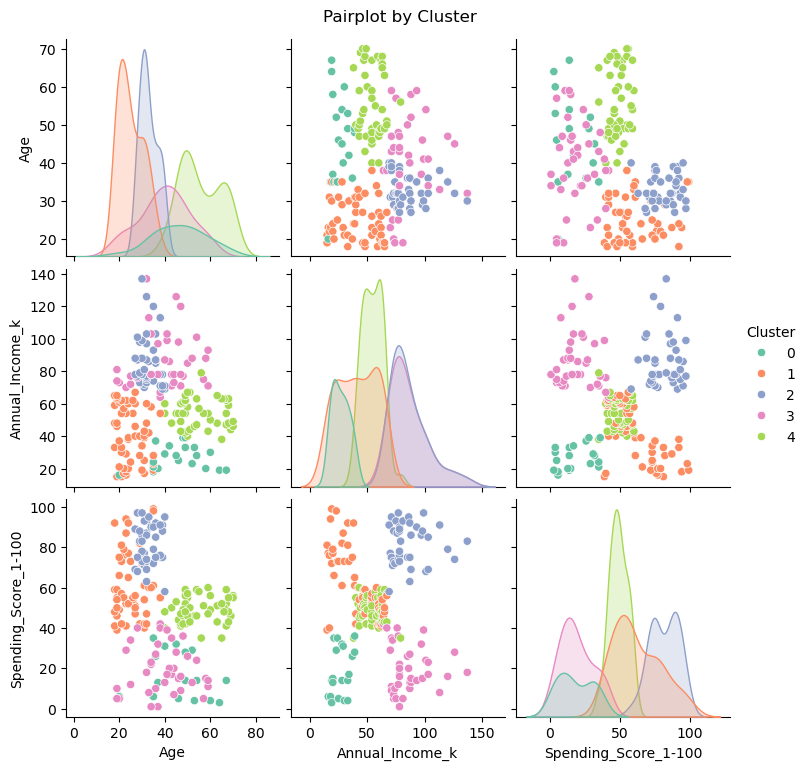

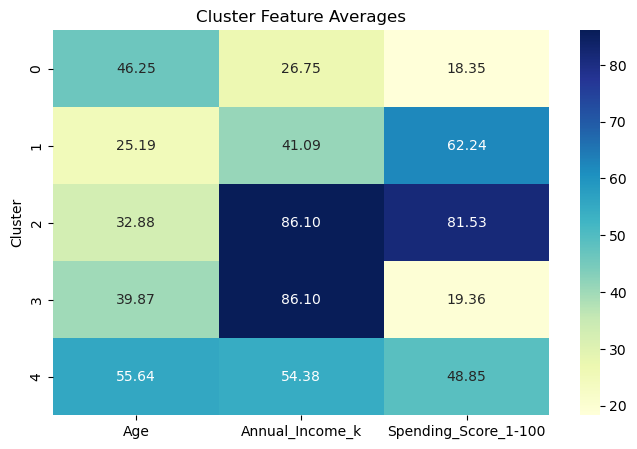

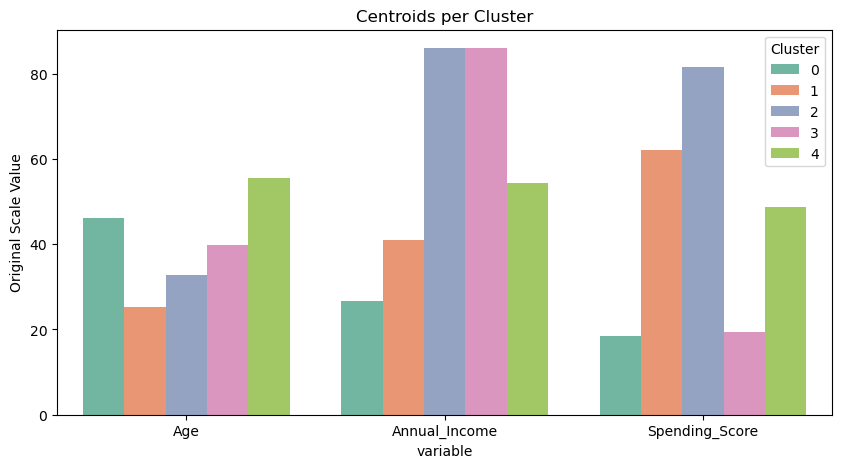


Cluster Summary:
           Age  Annual_Income_k  Spending_Score_1-100
Cluster                                              
0        46.25            26.75                 18.35
1        25.19            41.09                 62.24
2        32.88            86.10                 81.53
3        39.87            86.10                 19.36
4        55.64            54.38                 48.85

Recommendations:

Cluster 0:
  🔹 Low income segment – offer discounts or entry-level products.

Cluster 1:
  🔹 Moderate income and spending – nurture with standard marketing.

Cluster 2:
  🔹 High spenders with high income – target with premium products and loyalty programs.

Cluster 3:
  🔹 High income but low spending – investigate barriers or target with personalized offers.

Cluster 4:
  🔹 Moderate income and spending – nurture with standard marketing.


In [4]:
# Task 3: Clustering Analysis – Customer Segmentation

# Step 0: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Step 1: Load the Dataset
# Dataset name: customer_data.csv (change to your file path if using locally)
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/customers.csv"
df = pd.read_csv(url)

# Rename columns for consistency
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("(", "").str.replace(")", "").str.replace("$", "")

# Inspect the Dataset
print("Shape of dataset:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Data types:\n", df.dtypes)
print("Summary statistics:\n", df.describe())

# Step 2: Data Preprocessing
features = df[["Age", "Annual_Income_k", "Spending_Score_1-100"]]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 3: Determine Optimal Clusters using Elbow Method and Silhouette Score
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 5))
plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, marker='s', color='orange')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# Choose optimal k based on the above plots (e.g., 5)
optimal_k = 5

# Step 4: Apply K-Means Clustering
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_features)

# Step 5: PCA for 2D Visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)
df["PCA1"] = pca_components[:, 0]
df["PCA2"] = pca_components[:, 1]

# Step 6: Visualizations

# 1. 2D Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x="PCA1", y="PCA2", hue="Cluster", data=df, palette="Set2", s=100, edgecolor='k')
plt.title("Customer Segments (2D PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# 2. Pairplot with Clusters
sns.pairplot(df[["Age", "Annual_Income_k", "Spending_Score_1-100", "Cluster"]], hue="Cluster", palette="Set2")
plt.suptitle("Pairplot by Cluster", y=1.02)
plt.show()

# 3. Heatmap of Feature Means by Cluster
plt.figure(figsize=(8, 5))
cluster_means = df.groupby("Cluster")[["Age", "Annual_Income_k", "Spending_Score_1-100"]].mean()
sns.heatmap(cluster_means, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Cluster Feature Averages")
plt.show()

# 4. Centroid Visual
centroids = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids)

centroid_df = pd.DataFrame(centroids_original, columns=["Age", "Annual_Income", "Spending_Score"])
centroid_df["Cluster"] = range(optimal_k)

plt.figure(figsize=(10, 5))
sns.barplot(data=pd.melt(centroid_df, id_vars="Cluster"), x="variable", y="value", hue="Cluster", palette="Set2")
plt.title("Centroids per Cluster")
plt.ylabel("Original Scale Value")
plt.show()

# Step 7: Cluster Summary
print("\nCluster Summary:")
summary = df.groupby("Cluster")[["Age", "Annual_Income_k", "Spending_Score_1-100"]].mean().round(2)
print(summary)

# Step 8: Recommendations
print("\nRecommendations:")
for i in range(optimal_k):
    group = summary.loc[i]
    print(f"\nCluster {i}:")
    if group["Spending_Score_1-100"] > 60 and group["Annual_Income_k"] > 70:
        print("  🔹 High spenders with high income – target with premium products and loyalty programs.")
    elif group["Spending_Score_1-100"] < 40 and group["Annual_Income_k"] > 70:
        print("  🔹 High income but low spending – investigate barriers or target with personalized offers.")
    elif group["Annual_Income_k"] < 40:
        print("  🔹 Low income segment – offer discounts or entry-level products.")
    else:
        print("  🔹 Moderate income and spending – nurture with standard marketing.")

# Save Clustered Dataset (optional)
# df.to_csv("customer_segmented.csv", index=False)
